In [3]:
import time

import numpy as np
from scipy.stats import lognorm

import gurobipy as gp
from gurobipy import GRB
import cvxpy as cp

from tqdm import tqdm

from matplotlib import pyplot as plt

## 1. Исходная (номинальная) задача

Рассмотрим классическую задачу ресурсного распределения в «прямом» виде:

$$
\begin{aligned}
\max_{x\in\mathbb{R}^n_+}\quad & r^\top x,\\
\text{s.t.}\quad & A\,x \;\le\; b,
\end{aligned}
$$

где

* $x_i\ge0$ — объём $i$-го решения,
* $r\in\mathbb{R}^n$ — вектор выгод (цена единицы $i$-го решения),
* $A\in\mathbb{R}^{m\times n}$ — матрица затрат ресурсов,
* $b\in\mathbb{R}^m$ — доступные бюджеты по $m$ ресурсам.

В этой постановке мы считаем $A$ и $r$ точно известными.

---

## 2. Введение неопределённости и бюджет

Вводим **бюджет** для каждой строки-ограничения $j$:

$$
a_{ij} \;=\;\bar a_{ij} + d_{ij}\,z_{ij},
\quad
z_{ij}\in[-1,1],
\quad
\sum_{i=1}^n |z_{ij}|\le \Gamma_j.
$$

Здесь

* $\bar A$ — номинальная (средняя) матрица затрат,
* $D=(d_{ij})$ — масштабы отклонений,
* $z_j=(z_{1j},\dots,z_{nj})$ — вектор, каждый компонент ограничен $\pm1$,
* $\Gamma_j$ — **бюджет неопределённости**: сколько компонентов $z_{ij}$ может «отклониться» одновременно.

---

## 3. «Робастная» формулировка

Чтобы гарантировать допустимость при любых реализациях $a_{ij}$ из этого множества, для каждого $j$-го ограничения мы потребуем:

$$
\max_{\,z_j:\,|z_{ij}|\le1,\;\sum_i|z_{ij}|\le\Gamma_j}
\sum_{i=1}^n \bigl(\bar a_{ij} + d_{ij}z_{ij}\bigr)\,x_i
\;\le\; b_j.
$$

Вынесем номинальную и «неустойчивую» части:

$$
\sum_{i=1}^n\bar a_{ij}x_i
\;+\;\underbrace{\max_{z_j}\sum_{i=1}^n d_{ij}\,x_i\,z_{ij}}_{\displaystyle\;h_j(x)} 
\;\le\; b_j.
$$

И, наконец, полная **робастная** задача:

$$
\max_{x\ge0}\;r^\top x
\quad
\text{s.t.}\quad
\sum_{i=1}^n\bar a_{ij}x_i + h_j(x)\le b_j,\;\;j=1,\dots,m.
\tag{R}
$$

---

## 4. Внутренний максимум как LP

Функция

$$
h_j(x) \;=\;\max_{z_j}\;\sum_{i=1}^n d_{ij}\,x_i\,z_{ij}
\quad\text{s.t.}\quad
|z_{ij}|\le1,\;\sum_{i=1}^n|z_{ij}|\le\Gamma_j
$$

сама по себе — линейная задача максимизации по переменным $z_{ij}$. Запишем её в стандартном виде, введя вспомогательные неотрицательные переменные $t_{ij}\ge0$ такие, что

$$
|z_{ij}|\le t_{ij},\quad t_{ij}\le1,\quad \sum_{i}t_{ij}\le\Gamma_j.
$$

Тогда можно считать

$$
h_j(x) = \max_{z,t}\;\sum_{i}d_{ij}\,x_i\,z_{ij}
\;\;\text{s.t.}\;\;
\begin{cases}
-z_{ij}\le t_{ij},\\
z_{ij}\le t_{ij},\\
t_{ij}\le1,\\
\sum_i t_{ij}\le\Gamma_j,\\
t_{ij}\ge0.
\end{cases}
$$

Это LP с переменными $\{z_{ij},t_{ij}\}$.

---

## 5. Двойственная задача к $h_j(x)$

По теореме сильного двойственства LP можно записать как

$$
h_j(x) 
= 
\min_{\substack{\theta_j\ge0,\\\mu_{ij}\ge0}}
\Bigl\{\Gamma_j\,\theta_j + \sum_{i=1}^n\mu_{ij}\Bigr\}
\quad\text{s.t.}\quad
\theta_j + \mu_{ij} \;\ge\; d_{ij}\,x_i,\quad\forall i.
$$

Здесь

* $\theta_j$ — двойственная переменная, соответствующая ограничению $\sum_i t_{ij}\le\Gamma_j$,
* $\mu_{ij}$ — двойственные переменные при $t_{ij}\le1$ (связанные с обеими неравенствами на $z_{ij}$, но совмещённые для краткости).

---

## 6. Замена «максимума» на «минимум»

Изначально в (R) стояло

$$
\sum_i\bar a_{ij}x_i \;+\;\underbrace{\max_{z_j}\dots}_{h_j(x)} \;\le\;b_j.
$$

Подставим представление $h_j(x)=\min_{\theta,\mu}\{\Gamma_j\theta_j+\sum_i\mu_{ij}\}$. Получаем условие

$$
\sum_i\bar a_{ij}x_i + 
\min_{\theta_j,\mu_{ij}\ge0}\Bigl[\Gamma_j\,\theta_j + \sum_i\mu_{ij}\Bigr]
\;\le\;b_j.
$$

Поскольку $\min_y f(y) + g(x) \le b$ эквивалентно «существует $y$, такое что $g(x)+f(y)\le b$», мы приходим к совокупности линеарных ограничений:

$$
\exists\,\theta_j\ge0,\;\mu_{ij}\ge0:\quad
\sum_{i=1}^n\bar a_{ij}x_i \;+\;\Gamma_j\,\theta_j \;+\;\sum_{i=1}^n\mu_{ij}
\;\le\;b_j,
$$

$$
\theta_j+\mu_{ij}\;\ge\;d_{ij}\,x_i,
\quad
\forall i=1,\dots,n,\;j=1,\dots,m.
$$

---

## 7. Окончательная одноуровневая LP-модель

Итак, мы заменили «двухуровневую» max–sup задачу на стандартную LP:

$$
\begin{aligned}
\max_{x,\;\theta,\;\mu}\quad & r^\top x,\\
\text{s.t.}\quad 
&\sum_{i=1}^n\bar a_{ij}\,x_i \;+\;\Gamma_j\,\theta_j \;+\;
\sum_{i=1}^n\mu_{ij}\;\le\; b_j,
\quad j=1,\dots,m,\\
&\theta_j + \mu_{ij}\;\ge\;d_{ij}\,x_i,
\quad i=1,\dots,n,\;j=1,\dots,m,\\
&x_i\ge0,\;\theta_j\ge0,\;\mu_{ij}\ge0.
\end{aligned}
$$

Здесь

* $x$ — исходные решения,
* $\theta_j$ и $\mu_{ij}$ — дополнительные переменные, пришедшие из двойственной формулы для worst-case.


In [4]:
def generate_instances(n, m, N=100, seed=0):
    np.random.seed(seed)
    instances = []
    for _ in range(N):
        A0 = np.random.uniform(1, 10, (n, m))
        D  = np.random.uniform(0.1, 2, (n, m))
        r  = np.random.uniform(5, 20, n)
        b  = np.random.uniform(50, 100, m)
        instances.append((A0, D, r, b))
        
    return instances

In [5]:
def compute_in_sample(z_hat, z_true):
    return z_hat, z_hat / z_true

def compute_out_of_sample(c_star, x_hat, z_true):
    cost = c_star.dot(x_hat)
    return cost, cost / z_true

In [6]:
def solve_robust(A0, D, r, b, Gamma):

    n, m = A0.shape
    model = gp.Model()
    x      = model.addVars(n, lb=0, name="x")
    theta  = model.addVars(m, lb=0, name="theta")
    mu     = model.addVars(n, m, lb=0, name="mu")
    
    model.setObjective(
        gp.quicksum(r[i]*x[i] for i in range(n)), GRB.MAXIMIZE
    )
    
    for j in range(m):
        model.addConstr(
            gp.quicksum(A0[i,j]*x[i] for i in range(n))
            + Gamma[j]*theta[j]
            + gp.quicksum(mu[i,j] for i in range(n))
            <= b[j],
            name=f"res_j{j}"
        )
        for i in range(n):
            model.addConstr(
                theta[j] + mu[i,j] >= D[i,j]*x[i],
                name=f"rob_j{j}_i{i}"
            )
            
    model.Params.OutputFlag = 0
    t0 = time.time()
    model.optimize()
    t1 = time.time()
    
    x_opt = np.array([x[i].X for i in range(n)])
    
    return x_opt, model.ObjVal, t1-t0


def solve_nominal(A0, r, b):

    n, m = A0.shape
    model = gp.Model()
    x = model.addVars(n, lb=0, name="x_nom")
    model.setObjective(gp.quicksum(r[i] * x[i] for i in range(n)), GRB.MAXIMIZE)
    for j in range(m):
        model.addConstr(
            gp.quicksum(A0[i,j] * x[i] for i in range(n)) <= b[j],
            name=f"nom_constr_{j}"
        )
    model.Params.OutputFlag = 0
    model.optimize()
    
    return model.ObjVal


def evaluate_performance(Gammas):

    all_results = {}
    for n in tqdm(range(5, 51, 5)):
        instances = generate_instances(n=n, m=20, N=100, seed=54)
    
        results = {}
        for (A0, D, r, b) in instances:
            n, m = A0.shape
            
            z_true = solve_nominal(A0, r, b)
            
            for Gamma_val in Gammas:
                Gamma_vec = np.full(m, Gamma_val)
                x_hat, z_hat, t = solve_robust(A0, D, r, b, Gamma_vec)
                
                c_star = r + np.random.uniform(-1, 1, n)
                
                zin, rho_in   = compute_in_sample(z_hat, z_true)
                zout, rho_out = compute_out_of_sample(c_star, x_hat, z_true)
                
                results.setdefault((n, Gamma_val), []).append({
                    'zin':   zin, 
                    'in_sample':   rho_in,
                    'zout':  zout, 
                    'out_of_sample':  rho_out,
                    'time':  t
                })
        all_results.update(results)
        
    return all_results

In [7]:
results = evaluate_performance(Gammas=[0, 5, 10, 15, 20])

  0%|          | 0/10 [00:00<?, ?it/s]

Restricted license - for non-production use only - expires 2026-11-23


100%|██████████| 10/10 [01:01<00:00,  6.20s/it]


In [8]:
def plot_metrics(results, metric):
    """Для каждого n рисует линию метрики metric(Γ) и добавляет легенду."""
    data = {}
    for (n, G), recs in results.items():
        mean_val = np.mean([r[metric] for r in recs])
        std_val = np.std([r[metric] for r in recs])
        data.setdefault(n, []).append((G, mean_val, std_val))
    
    plt.figure(figsize=(8,5))
    
    for n, points in sorted(data.items()):
        points.sort(key=lambda x: x[0])
        Gs, means, stds = zip(*points)
        plt.errorbar(Gs, means, yerr=stds, label=f'n={n}', capsize=5)
        
    plt.xlabel("Γ")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Γ для разных n")
    plt.legend(title="Размерность n")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_time_vs_n(results, Gammas):
    plt.figure(figsize=(8,5))
    for G in Gammas:
        ns = sorted({n for (n,g) in results.keys() if g==G})
        times = [np.mean([r['time'] for r in results[(n,G)]]) for n in ns]
        plt.plot(ns, times, marker='s', label=f'Γ={G}')
        
    plt.xlabel("n")
    plt.ylabel("Среднее время, с")
    plt.title("Время решения vs n для разных Γ")
    plt.legend(title="Γ")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

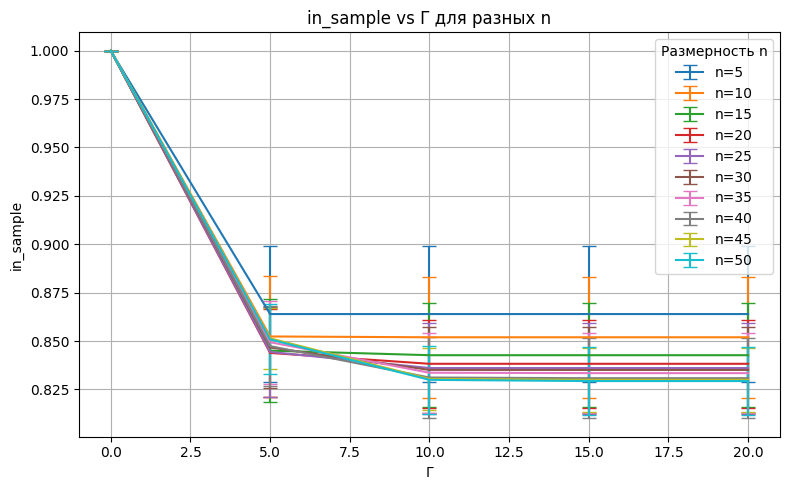

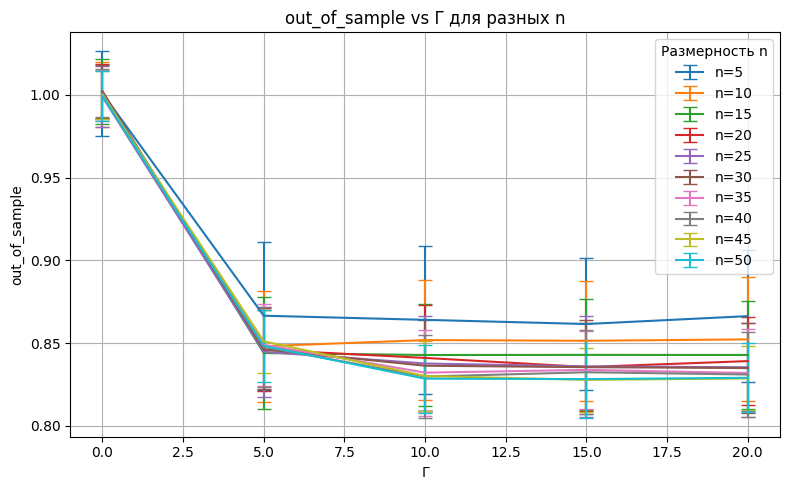

In [9]:
plot_metrics(results, metric='in_sample')
plot_metrics(results, metric='out_of_sample')

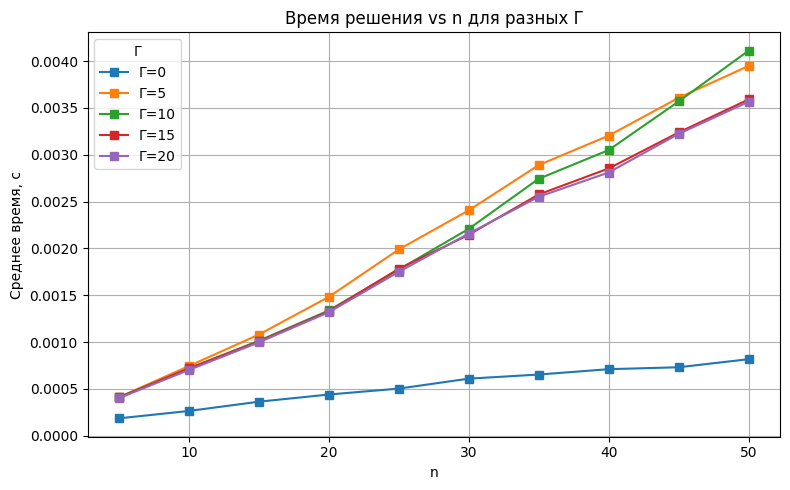

In [10]:
plot_time_vs_n(results, Gammas=[0, 5, 10, 15, 20])

# Stochastic programming approach

Предположим, что выгоды r_i следуют логнормальному распределению:

r_i ~ LogNormal(μ=1, σ=0.5)

## Формулировка стохастических задач и их SAA аппроксимаций

Исходную задачу

\begin{aligned}
&\max_x \sum_{i=1}^n r_i x_i \\
&\text{s.t. } \sum_{i=1}^n a_{ij} x_i \leq b_j, \forall j \in \{1,...,m\} \\
&x_i \geq 0, \forall i \in \{1,...,n\}
\end{aligned}

Рассмотрим как задачу на минимум

\begin{aligned}
&\min_x \sum_{i=1}^n - r_i x_i \\
&\text{s.t. } \sum_{i=1}^n a_{ij} x_i \leq b_j, \forall j \in \{1,...,m\} \\
&x_i \geq 0, \forall i \in \{1,...,n\}
\end{aligned}

###  Risk-neutral

**Исходная формулировка:**

\begin{aligned}
&\min_x \mathbb-{E}[r]^T x \\
&\text{s.t. } Ax \leq b \\
&x \geq 0
\end{aligned}

**SAA аппроксимация:**

\begin{aligned}
&\min_x -\frac{1}{k}\sum_{s=1}^k r^{(s)T}x \\
&\text{s.t. } Ax \leq b \\
&x \geq 0
\end{aligned}

###  Risk-averse

**Исходная формулировка:**

\begin{aligned}
&\min_x \text{CVaR}_\alpha(- r^T x) \\
&\text{s.t. } Ax \leq b \\
&x \geq 0
\end{aligned}

**SAA аппроксимация:**

\begin{aligned}
&\min_{x,t} \left( t + \frac{1}{k(1-\alpha)}\sum_{s=1}^k z_s \right) \\
&\text{s.t. } Ax \leq b \\
&x \geq 0 \\
&z_s \geq 0 \\
&z_s \geq - t - r^{(s)T}x, \forall s
\end{aligned}

In [2]:
alpha = 0.9
k = 30
n_values = range(5, 51, 5)
num_instances = 10

sigma = 0.5
mu = 1

In [3]:
def generate_parameters(n):
    m = (int)(0.8 * n)
    a = np.random.uniform(0.5, 1.5, size=(n, m))
    b = np.random.uniform(5, 10, size=m)
    return a, b

def sample_r(n, size=1):
    return lognorm.rvs(s=sigma, scale=np.exp(mu), size=(size, n))

def solve_risk_neutral(a, b, r_samples):
    n = a.shape[0]
    x = cp.Variable(n)
    objective = cp.Minimize(-np.mean(r_samples, axis=0) @ x)
    constraints = [
        a.T @ x <= b,
        x >= 0
    ]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return x.value, objective.value

def solve_risk_averse(a, b, r_samples, alpha=0.9):
    n = a.shape[0]
    x = cp.Variable(n)
    t = cp.Variable()
    z = cp.Variable(len(r_samples))

    objective = cp.Minimize(t + 1/(len(r_samples)*(1-alpha)) * cp.sum(z))
    constraints = [
        a.T @ x <= b,
        x >= 0,
        z >= 0,
        z >= - t - r_samples @ x
    ]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return x.value, t.value, objective.value

def do_risk_neutral(r_samples, x):
    return -np.mean(r_samples @ x)

def do_risk_averse(r_samples, x, t, alpha):
    return t + 1/(1-alpha) * np.mean(np.maximum(-r_samples @ x - t, 0))

In [4]:
results = []

for n in n_values:
    print(f"Processing n={n}")
    neutral_times = []
    averse_times = []

    neutral_qualities_in = []
    neutral_qualities_out = []

    averse_qualities_in = []
    averse_qualiies_out = []

    cross_error_neutral = []
    cross_error_averse = []

    for _ in range(num_instances):
        a, b = generate_parameters(n)

        train_samples = sample_r(n, size=k)
        test_samples = sample_r(n, size=10000)

        # risk neutral
        start = time.time()
        x_neutral, Z_train_star = solve_risk_neutral(a, b, train_samples)
        neutral_time = time.time() - start
        neutral_times.append(neutral_time)

        x_star, Z_star = solve_risk_neutral(a, b, test_samples)
        neutral_qualities_in.append(Z_train_star / Z_star)
        neutral_qualities_out.append(do_risk_neutral(test_samples, x_neutral) / Z_star)

        # risk averse
        start = time.time()
        x_averse, t_averse, Z_train_star = solve_risk_averse(a, b, train_samples, alpha)
        averse_time = time.time() - start
        averse_times.append(averse_time)

        cross_error_neutral.append(do_risk_neutral(test_samples, x_averse) / Z_star)

        _, _, Z_star = solve_risk_averse(a, b, test_samples, alpha)
        averse_qualities_in.append(Z_train_star / Z_star)
        averse_qualiies_out.append(do_risk_averse(test_samples, x_averse, t_averse, alpha) / Z_star)

        cross_error_averse.append(do_risk_averse(test_samples, x_neutral, t_averse, alpha) / Z_star)

    results.append({
        'n': n,
        'avg_neutral_time': np.mean(neutral_times),
        'avg_averse_time': np.mean(averse_times),
        'rho_in_neutral_mean': np.mean(neutral_qualities_in),
        'rho_in_neutral_std': np.std(neutral_qualities_in),
        'rho_out_neutral_mean': np.mean(neutral_qualities_out),
        'rho_out_neutral_std': np.std(neutral_qualities_out),
        'rho_in_averse_mean': np.mean(averse_qualities_in),
        'rho_in_averse_std': np.std(averse_qualities_in),
        'rho_out_averse_mean': np.mean(averse_qualiies_out),
        'rho_out_averse_std': np.std(averse_qualiies_out),
        'cross_error_neutral_mean': np.mean(cross_error_neutral),
        'cross_error_neutral_std': np.std(cross_error_neutral),
        'cross_error_averse_mean': np.mean(cross_error_averse),
        'cross_error_averse_std': np.std(cross_error_averse)
    })

Processing n=5
Processing n=10
Processing n=15
Processing n=20
Processing n=25
Processing n=30
Processing n=35
Processing n=40
Processing n=45
Processing n=50


In [5]:
for res in results:
    n = res['n']
    print(f"n = {n}:")

    print(f"  Risk-Neutral:")
    print(f"    ρ_in  = {res['rho_in_neutral_mean']:.4f} ± {res['rho_in_neutral_std']:.4f}")
    print(f"    ρ_out = {res['rho_out_neutral_mean']:.4f} ± {res['rho_out_neutral_std']:.4f}")
    print(f"    cross_error = {res['cross_error_neutral_mean']:.4f} ± {res['cross_error_neutral_std']:.4f}")

    print(f"  Risk-Averse:")
    print(f"    ρ_in  = {res['rho_in_averse_mean']:.4f} ± {res['rho_in_averse_std']:.4f}")
    print(f"    ρ_out = {res['rho_out_averse_mean']:.4f} ± {res['rho_out_averse_std']:.4f}")
    print(f"    cross_error = {res['cross_error_averse_mean']:.4f} ± {res['cross_error_averse_std']:.4f}")

    print("-" * 60)

n = 5:
  Risk-Neutral:
    ρ_in  = 1.0602 ± 0.0504
    ρ_out = 0.9911 ± 0.0127
    cross_error = 0.9177 ± 0.0530
  Risk-Averse:
    ρ_in  = 1.0711 ± 0.0616
    ρ_out = 0.9258 ± 0.0636
    cross_error = 0.6989 ± 0.1769
------------------------------------------------------------
n = 10:
  Risk-Neutral:
    ρ_in  = 1.0450 ± 0.0496
    ρ_out = 0.9720 ± 0.0246
    cross_error = 0.9172 ± 0.0289
  Risk-Averse:
    ρ_in  = 1.1068 ± 0.0651
    ρ_out = 0.8423 ± 0.0887
    cross_error = 0.6438 ± 0.2030
------------------------------------------------------------
n = 15:
  Risk-Neutral:
    ρ_in  = 1.0433 ± 0.0434
    ρ_out = 0.9713 ± 0.0182
    cross_error = 0.9218 ± 0.0499
  Risk-Averse:
    ρ_in  = 1.1170 ± 0.0526
    ρ_out = 0.7672 ± 0.1077
    cross_error = 0.5145 ± 0.2575
------------------------------------------------------------
n = 20:
  Risk-Neutral:
    ρ_in  = 1.0517 ± 0.0462
    ρ_out = 0.9714 ± 0.0348
    cross_error = 0.9237 ± 0.0318
  Risk-Averse:
    ρ_in  = 1.1495 ± 0.0569
    

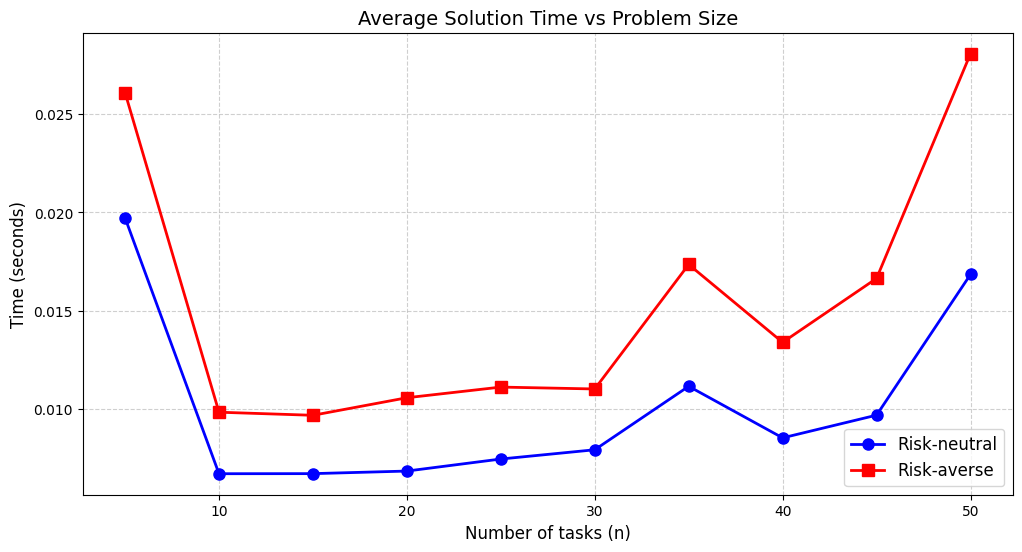

In [6]:
n_values = [res['n'] for res in results]
neutral_times = [res['avg_neutral_time'] for res in results]
averse_times = [res['avg_averse_time'] for res in results]

plt.figure(figsize=(12, 6))

plt.plot(n_values, neutral_times, 'bo-', label='Risk-neutral', linewidth=2, markersize=8)
plt.plot(n_values, averse_times, 'rs-', label='Risk-averse', linewidth=2, markersize=8)

plt.title('Average Solution Time vs Problem Size', fontsize=14)
plt.xlabel('Number of tasks (n)', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)